In [75]:
import sys
import numpy as np
import matplotlib.pyplot as plt

G = 6.67 * 10 ** -11
M = 10 ** 35
c = 3 * 10 ** 8
D_s = 10 ** 21
D_d = 10**20
D_ds = 9*10**20

θ_E = np.sqrt((4*G*M)/(c**2)*D_ds/(D_d*D_s))

print(θ_E)

β_list = [[0,0], [0.5*θ_E,0.5*θ_E], [-θ_E,θ_E]]

print(β_list)


1.6334013591276333e-06
[[0, 0], [8.167006795638167e-07, 8.167006795638167e-07], [-1.6334013591276333e-06, 1.6334013591276333e-06]]


In [79]:
β = np.array(β_list[2])

β_mag = np.linalg.norm(β)

if β_mag != 0:
    factor_p = 0.5 * (1 + np.sqrt(1 + 4*θ_E**2 / β_mag**2))
    factor_n = 0.5 * (1 - np.sqrt(1 + 4*θ_E**2 / β_mag**2))
else:
    print('Einstein Ring')
    factor_p = 0
    factor_n = 0

θ_p = factor_p * β
θ_n = factor_n * β

print("β =", β)
print("θ+ =", θ_p)
print("θ- =", θ_n)

theta_p_mag = np.linalg.norm(θ_p)
theta_n_mag = np.linalg.norm(θ_n)

mu_p = (theta_p_mag / β_mag) * 1 / (1 + (θ_E**2 / theta_p_mag**2))
mu_n = (theta_n_mag / β_mag) * 1 / (1 + (θ_E**2 / theta_n_mag**2))

print("μ+ =", mu_p)
print("μ- =", mu_n)

β = [-1.63340136e-06  1.63340136e-06]
θ+ = [-2.23126775e-06  2.23126775e-06]
θ- = [ 5.97866392e-07 -5.97866392e-07]
μ+ = 1.0773502691896262
μ- = 0.07735026918962579


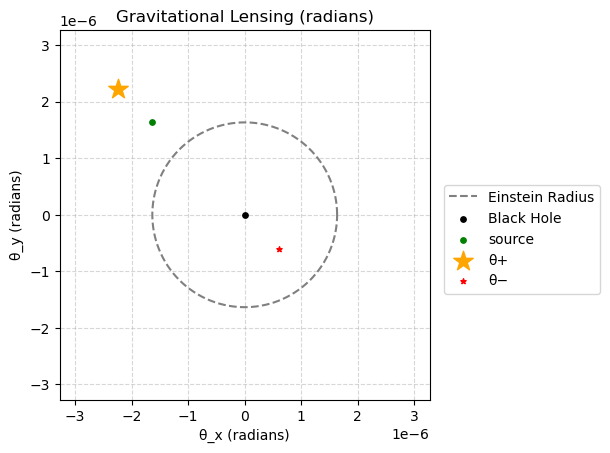

In [101]:
fig, ax = plt.subplots()

theta = np.linspace(0, 2*np.pi, 500)
x = θ_E * np.cos(theta)
y = θ_E * np.sin(theta)
ax.plot(x, y, label="Einstein Radius", color='gray', ls='--')

ax.scatter(0, 0, color='black', s=15, label='Black Hole', zorder=5)
ax.scatter(β[0], β[1], color='green', s=15, label='source', zorder=5)

if β_mag < 1e-15:   # beta ≈ 0
    
    ax.plot(x, y, label="Einstein Ring", color='blue')

else:
    ax.scatter(θ_p[0], θ_p[1], marker='*', color='orange', s=200*mu_p, label='θ+')
    ax.scatter(θ_n[0], θ_n[1], marker='*', color='red', s=200*mu_n, label='θ−')


limit = 2 * θ_E   # show a few Einstein radii
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)


ax.set_aspect('equal', adjustable='box')


ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))


ax.set_xlabel("θ_x (radians)")
ax.set_ylabel("θ_y (radians)")
ax.set_title("Gravitational Lensing (radians)")


ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(1.25, 0.6), ncol=1)

plt.show()